In [17]:
# ---- importing the stuff I need ----
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# ---- loading in the dataset files ----
matches = pd.read_csv('/content/drive/MyDrive/matches.csv')
participants = pd.read_csv('/content/drive/MyDrive/participants.csv')
teamstats = pd.read_csv('/content/drive/MyDrive/teamstats.csv')

print("look at matches:")
print(matches.head())

look at matches:
   id      gameid platformid  queueid  seasonid  duration       creation  \
0  10  3187427022       EUW1      420         8      1909  1495068946860   
1  11  3187425281       EUW1      420         8      1693  1495066760778   
2  12  3187269801       EUW1      420         8      1482  1495053375889   
3  13  3187252065       EUW1      420         8      1954  1495050993613   
4  14  3187201038       EUW1      420         8      2067  1495047893400   

         version  
0  7.10.187.9675  
1  7.10.187.9675  
2  7.10.187.9675  
3  7.10.187.9675  
4  7.10.187.9675  


In [20]:
# ---- combining the tables so everything is in one place ----
# I’m merging player data with team results so I know who won each match

def determine_winner(group):
    if group['inhibkills'].iloc[0] > group['inhibkills'].iloc[1]:
        group.loc[group.index[0], 'win'] = 1
        group.loc[group.index[1], 'win'] = 0
    elif group['inhibkills'].iloc[1] > group['inhibkills'].iloc[0]:
        group.loc[group.index[1], 'win'] = 1
        group.loc[group.index[0], 'win'] = 0
    elif group['towerkills'].iloc[0] > group['towerkills'].iloc[1]:
        group.loc[group.index[0], 'win'] = 1
        group.loc[group.index[1], 'win'] = 0
    elif group['towerkills'].iloc[1] > group['towerkills'].iloc[0]:
        group.loc[group.index[1], 'win'] = 1
        group.loc[group.index[0], 'win'] = 0
    else:
        group['win'] = 0
    return group

teamstats = teamstats.groupby('matchid').apply(determine_winner).reset_index(drop=True)

participants['teamid'] = participants['player'].apply(lambda x: 100 if x <= 5 else 200)

full_data = participants.merge(
    teamstats[['matchid', 'teamid', 'win']],
    on=['matchid','teamid'],
    how='left'
)

print("\nAfter merging everything together:")
print(full_data.head())

/tmp/ipykernel_10264/2974007775.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  teamstats = teamstats.groupby('matchid').apply(determine_winner).reset_index(drop=True)



After merging everything together:
   id  matchid  player  championid  ss1  ss2         role position  teamid  \
0   9       10       1          19    4   11         NONE   JUNGLE     100   
1  10       10       2         267    3    4  DUO_SUPPORT      BOT     100   
2  11       10       3         119    7    4    DUO_CARRY      BOT     100   
3  12       10       4         114   12    4         SOLO      TOP     100   
4  13       10       5         112    4    3         SOLO      MID     100   

   win  
0  0.0  
1  0.0  
2  0.0  
3  0.0  
4  0.0  


In [21]:
print("Columns in teamstats DataFrame:")
print(teamstats.columns.tolist())

Columns in teamstats DataFrame:
['matchid', 'teamid', 'firstblood', 'firsttower', 'firstinhib', 'firstbaron', 'firstdragon', 'firstharry', 'towerkills', 'inhibkills', 'baronkills', 'dragonkills', 'harrykills', 'win']


In [22]:
print("Columns in matches DataFrame:")
print(matches.columns.tolist())

Columns in matches DataFrame:
['id', 'gameid', 'platformid', 'queueid', 'seasonid', 'duration', 'creation', 'version']


In [23]:
# ---- checking the data before doing anything serious ----
print("\nMissing values:")
print(full_data.isnull().sum())


Missing values:
id            0
matchid       0
player        0
championid    0
ss1           0
ss2           0
role          0
position      0
teamid        0
win           0
dtype: int64


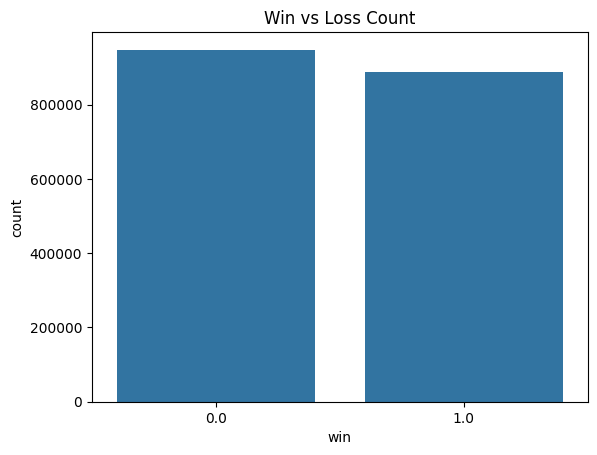

In [24]:
# quick visual to see how wins vs losses are distributed
sns.countplot(x='win', data=full_data)
plt.title('Win vs Loss Count')
plt.show()

In [25]:
# ---- figuring out win percentages ----
overall_win_percentage = full_data['win'].mean() * 100
print(f"\nOverall Win Rate: {overall_win_percentage:.2f}%")


Overall Win Rate: 48.33%



Win rate by team:
teamid
100    49.734663
200    46.923479
Name: win, dtype: float64


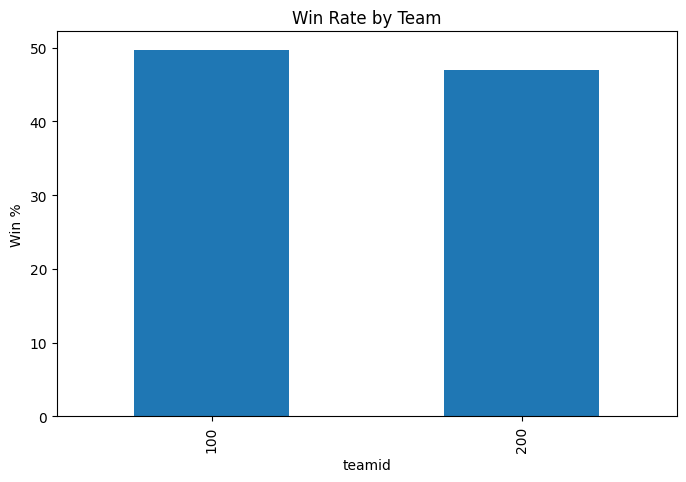

In [27]:
# ---- figuring out win percentages ----
team_win_percentages = full_data.groupby('teamid')['win'].mean() * 100
print("\nWin rate by team:")
print(team_win_percentages)
team_win_percentages.plot(kind='bar', figsize=(8,5))
plt.ylabel('Win %')
plt.title('Win Rate by Team')
plt.show()

In [32]:
# ---- picking which stats I want the model to learn from ----
features = ['kills','deaths','assists','goldEarned','totalDamageDealt']
X = full_data[features]
y = full_data['win']
X = X.fillna(0)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# ---- training the model ----
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [36]:
# ---- seeing how well the model did ----
y_pred = model.predict(X_test_scaled)

print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred):.2f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nMore detailed stats:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.67

Confusion Matrix:
[[166114  23273]
 [ 99590  77927]]

More detailed stats:
              precision    recall  f1-score   support

         0.0       0.63      0.88      0.73    189387
         1.0       0.77      0.44      0.56    177517

    accuracy                           0.67    366904
   macro avg       0.70      0.66      0.64    366904
weighted avg       0.70      0.67      0.65    366904



In [37]:
# ---- getting win probabilities instead of just win/loss ----
win_prob = model.predict_proba(X_test_scaled)[:,1]

print("\nSample win probability predictions:")
for i, prob in enumerate(win_prob[:5]):
    print(f"Game {i+1}: {prob*100:.2f}% chance to win")


Sample win probability predictions:
Game 1: 57.61% chance to win
Game 2: 55.35% chance to win
Game 3: 17.36% chance to win
Game 4: 37.70% chance to win
Game 5: 45.28% chance to win


In [29]:
print("Columns in full_data DataFrame:")
print(full_data.columns.tolist())

Columns in full_data DataFrame:
['id', 'matchid', 'player', 'championid', 'ss1', 'ss2', 'role', 'position', 'teamid', 'win']


In [30]:
# Load the potential performance data from stats1.csv
player_stats = pd.read_csv('/content/drive/MyDrive/stats1.csv')

print("Columns in player_stats DataFrame:")
print(player_stats.columns.tolist())
print("\nFirst 5 rows of player_stats:")
print(player_stats.head())

Columns in player_stats DataFrame:
['id', 'win', 'item1', 'item2', 'item3', 'item4', 'item5', 'item6', 'trinket', 'kills', 'deaths', 'assists', 'largestkillingspree', 'largestmultikill', 'killingsprees', 'longesttimespentliving', 'doublekills', 'triplekills', 'quadrakills', 'pentakills', 'legendarykills', 'totdmgdealt', 'magicdmgdealt', 'physicaldmgdealt', 'truedmgdealt', 'largestcrit', 'totdmgtochamp', 'magicdmgtochamp', 'physdmgtochamp', 'truedmgtochamp', 'totheal', 'totunitshealed', 'dmgselfmit', 'dmgtoobj', 'dmgtoturrets', 'visionscore', 'timecc', 'totdmgtaken', 'magicdmgtaken', 'physdmgtaken', 'truedmgtaken', 'goldearned', 'goldspent', 'turretkills', 'inhibkills', 'totminionskilled', 'neutralminionskilled', 'ownjunglekills', 'enemyjunglekills', 'totcctimedealt', 'champlvl', 'pinksbought', 'wardsbought', 'wardsplaced', 'wardskilled', 'firstblood']

First 5 rows of player_stats:
   id  win  item1  item2  item3  item4  item5  item6  trinket  kills  ...  \
0   9    0   3748   2003   3

In [31]:
# Merge player_stats into full_data based on the 'id' column
full_data = full_data.merge(player_stats[['id', 'kills', 'deaths', 'assists', 'goldearned', 'totdmgdealt']], on='id', how='left')

full_data.rename(columns={'totdmgdealt': 'totalDamageDealt', 'goldearned': 'goldEarned'}, inplace=True)

print("\nColumns in full_data DataFrame after merging player stats:")
print(full_data.columns.tolist())
print("\nFirst 5 rows of full_data after merging:")
print(full_data.head())


Columns in full_data DataFrame after merging player stats:
['id', 'matchid', 'player', 'championid', 'ss1', 'ss2', 'role', 'position', 'teamid', 'win', 'kills', 'deaths', 'assists', 'goldEarned', 'totalDamageDealt']

First 5 rows of full_data after merging:
   id  matchid  player  championid  ss1  ss2         role position  teamid  \
0   9       10       1          19    4   11         NONE   JUNGLE     100   
1  10       10       2         267    3    4  DUO_SUPPORT      BOT     100   
2  11       10       3         119    7    4    DUO_CARRY      BOT     100   
3  12       10       4         114   12    4         SOLO      TOP     100   
4  13       10       5         112    4    3         SOLO      MID     100   

   win  kills  deaths  assists  goldEarned  totalDamageDealt  
0  0.0    6.0    10.0      1.0     10497.0           96980.0  
1  0.0    0.0     2.0     12.0      9496.0           25995.0  
2  0.0    7.0     8.0      5.0     13136.0          171568.0  
3  0.0    5.0    11.